## LIBUNA, DONJIE C.
## VILLARUEL, LEANN M.
## BSCS - 3B AI | CCS-249 UNIT 6 EXERCISE

---


# **GPT-2 Fine-tuning on Jokes Dataset**
Fine-tuning `openai-community/gpt2` on the `Maximofn/short-jokes-dataset` from HuggingFace.


**Steps:**
1. Install dependencies
2. Imports & device check
3. Load model & tokenizer
4. Load & split dataset
5. Tokenize
6. Training configuration
7. Train
8. Save to Google Drive
9. Generate jokes
10. Perplexity evaluation
11. PCA visualization of word vectors

## Steps to be followed
1. **Task identified:** fine-tune a causal language model for joke generation.
2. **Domain identified:** short-humor / jokes text.
3. **LLM identified:** `openai-community/gpt2`.
4. **Fine-tuning configuration established:** tokenizer/model setup, train/eval split, tokenization, Trainer arguments.
5. **Evaluation performed:** generated joke samples, eval loss, perplexity, and PCA vector visualization.

## 1. Install Dependencies


In [17]:
!pip install transformers datasets accelerate matplotlib scikit-learn --quiet

## 2. Imports & Device Detection

In [18]:
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)
from datasets import load_dataset
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training on: {device.upper()}")

if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found. Go to Runtime → Change runtime type → T4 GPU")

print(f"PyTorch version: {torch.__version__}")

Training on: CUDA
GPU: Tesla T4
VRAM: 15.6 GB
PyTorch version: 2.10.0+cu128


## 3. Load Model & Tokenizer

In [19]:
model_name = "openai-community/gpt2"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token by default

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(model_name)
model.resize_token_embeddings(len(tokenizer))

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded — {total_params:,} parameters ({total_params/1e6:.1f}M)")

Loading tokenizer...
Loading model...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded — 124,439,808 parameters (124.4M)


## 4. Load & Split Dataset

In [20]:
print("Loading dataset...")
dataset = load_dataset("Maximofn/short-jokes-dataset", split="train")

print(f"Total jokes: {len(dataset):,}")
print("\nSample jokes:")
for i in range(3):
    print(f"  [{i+1}] {dataset[i]['Joke']}")

Loading dataset...
Total jokes: 231,657

Sample jokes:
  [1] [me narrating a documentary about narrators] "I can't hear what they're saying cuz I'm talking"
  [2] Telling my daughter garlic is good for you. Good immune system and keeps pests away.Ticks, mosquitos, vampires... men.
  [3] I've been going through a really rough period at work this week It's my own fault for swapping my tampax for sand paper.


In [21]:
# 95% train / 5% eval split
split = dataset.train_test_split(test_size=0.05, seed=42)
train_data = split["train"]
eval_data  = split["test"]

print(f"Train set: {len(train_data):,} jokes")
print(f"Eval set:  {len(eval_data):,} jokes")

Train set: 220,074 jokes
Eval set:  11,583 jokes


## 5. Tokenize Dataset

In [22]:
MAX_LENGTH = 128  # T4 has 16GB VRAM — can handle full 128 tokens comfortably

def tokenize(batch):
    return tokenizer(
        batch["Joke"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

print("Tokenizing train set...")
train_tokenized = train_data.map(tokenize, batched=True, remove_columns=["Joke"])

print("Tokenizing eval set...")
eval_tokenized = eval_data.map(tokenize, batched=True, remove_columns=["Joke"])

# DataCollator handles padding + labels automatically
collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # causal LM, not masked LM
)

print("Tokenization complete")

Tokenizing train set...
Tokenizing eval set...


Map:   0%|          | 0/11583 [00:00<?, ? examples/s]

Tokenization complete


## 6. Training Configuration


In [23]:
training_args = TrainingArguments(
    output_dir="./gpt2-jokes-output",

    # Training schedule
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,

    # Optimizer
    learning_rate=5e-5,
    warmup_steps=100,
    weight_decay=0.01,

    # Evaluation & saving
    eval_strategy="steps",
    eval_steps=500,
    save_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,

    # Logging
    logging_steps=100,
    logging_dir="./gpt2-jokes-logs",

    # Performance
    fp16=torch.cuda.is_available(),      # fp16 enabled on T4 GPU — faster + less memory
    report_to="none",                    # disable wandb / tensorboard
)

print("Training config ready")
print(f"   Epochs        : {training_args.num_train_epochs}")
print(f"   Batch size    : {training_args.per_device_train_batch_size}")
print(f"   Learning rate : {training_args.learning_rate}")
print(f"   fp16 (GPU)    : {training_args.fp16}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training config ready
   Epochs        : 3
   Batch size    : 16
   Learning rate : 5e-05
   fp16 (GPU)    : True


## 7. Train the Model

In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    data_collator=collator,
)

print("Starting training...")
print("Loss prints every 100 steps — lower is better\n")
trainer.train()

Starting training...
Loss prints every 100 steps — lower is better



Step,Training Loss,Validation Loss
500,3.792517,3.611957
1000,3.673354,3.528546
1500,3.648794,3.480677
2000,3.621072,3.446369
2500,3.570295,3.425144
3000,3.516075,3.400050
3500,3.527681,3.384881
4000,3.508094,3.368451
4500,3.475072,3.349004
5000,3.511137,3.340770


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=41265, training_loss=3.206444268253779, metrics={'train_runtime': 8112.0145, 'train_samples_per_second': 81.388, 'train_steps_per_second': 5.087, 'total_flos': 1.4011536172032e+16, 'train_loss': 3.206444268253779, 'epoch': 3.0})

## 8. Save Model to Google Drive
> Saves to Drive so the model is not lost when the Colab session ends.

In [25]:
from google.colab import drive
drive.mount("/content/drive")

save_path = "/content/drive/MyDrive/gpt2-jokes-finetuned"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to Google Drive: {save_path}")

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to Google Drive: /content/drive/MyDrive/gpt2-jokes-finetuned


## 9. Evaluation — Generate Jokes!

In [30]:
from transformers import pipeline
from IPython.display import display, HTML

generator = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

prompts = [
    'Why did the programmer',
    'Why did the chicken',
    'I told my computer',
]

results = []
for prompt in prompts:
    output = generator(
        prompt,
        max_new_tokens=40,
        num_return_sequences=1,
        do_sample=True,
        temperature=0.9,
        top_p=0.95,
        pad_token_id=tokenizer.eos_token_id
    )
    results.append((prompt, output[0]['generated_text']))

cards_html = '<div style="font-family:sans-serif;display:flex;flex-direction:column;gap:12px;padding:8px 0;">'

for i, (prompt, output) in enumerate(results, 1):
    cards_html += (
        f'<div style="border:1px solid #e5e7eb;border-radius:12px;padding:16px 20px;'
        f'background:#ffffff;display:grid;grid-template-columns:36px 1fr;gap:14px;align-items:start;">'
        f'<div style="width:36px;height:36px;border-radius:50%;background:#f3f4f6;'
        f'display:flex;align-items:center;justify-content:center;'
        f'font-size:13px;font-weight:600;color:#6b7280;">{i}</div>'
        f'<div>'
        f'<p style="margin:0 0 3px;font-size:11px;font-weight:600;color:#9ca3af;'
        f'text-transform:uppercase;letter-spacing:0.06em;">Prompt</p>'
        f'<p style="margin:0 0 12px;font-size:14px;color:#6b7280;font-style:italic;">"{prompt}\u2026"</p>'
        f'<p style="margin:0 0 3px;font-size:11px;font-weight:600;color:#9ca3af;'
        f'text-transform:uppercase;letter-spacing:0.06em;">Output</p>'
        f'<p style="margin:0;font-size:15px;color:#111827;line-height:1.6;">{output}</p>'
        f'</div></div>'
    )

cards_html += '</div>'
display(HTML(cards_html))

Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


## 10. Perplexity Evaluation
Perplexity measures how well the model predicts the eval set. **Lower = better.**

In [27]:
import math

eval_results = trainer.evaluate()
eval_loss = eval_results["eval_loss"]

if eval_loss < 0:
    eval_loss = 0.001

perplexity = min(math.exp(eval_loss), 1000)

print(f"Eval Loss   : {eval_loss:.4f}")
print(f"Perplexity  : {perplexity:.2f}")
print()
print("Guide:")
print("  < 30  → Great! Model learned joke structure well")
print("  30-60 → Decent, outputs will be mostly coherent")
print("  > 60  → Model is still confused — try more epochs")

Eval Loss   : 3.1094
Perplexity  : 22.41

Guide:
  < 30  → Great! Model learned joke structure well
  30-60 → Decent, outputs will be mostly coherent
  > 60  → Model is still confused — try more epochs


## 11. PCA Visualization of Word Vectors
Visualize learned embeddings using PCA with 24 joke-related words.

24 words extracted for PCA
Explained variance → PC1: 9.4%, PC2: 7.2%
PCA saved to Google Drive: /content/drive/MyDrive/pca_vectors.png


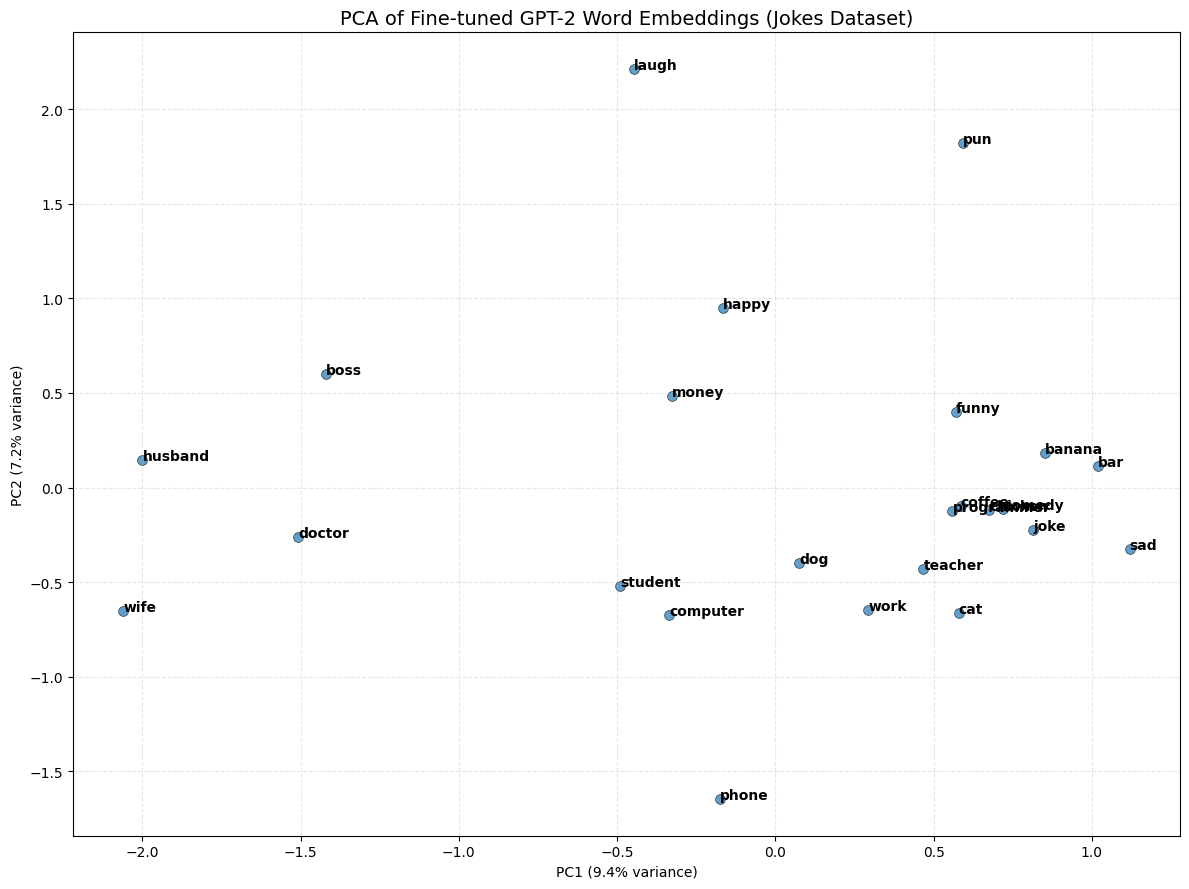

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 24 words for visualization
words = [
    "joke", "funny", "laugh", "comedy", "pun", "chicken", "programmer", "computer",
    "coffee", "teacher", "student", "doctor", "cat", "dog", "money", "work",
    "boss", "wife", "husband", "banana", "phone", "happy", "sad", "bar"
]

embedding_matrix = model.get_input_embeddings().weight.detach().cpu().numpy()

valid_words, word_vectors = [], []
for w in words:
    token_ids = tokenizer.encode(w, add_special_tokens=False)
    if not token_ids:
        continue
    vec = embedding_matrix[token_ids].mean(axis=0)
    valid_words.append(w)
    word_vectors.append(vec)

X = np.vstack(word_vectors)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

print(f"{len(valid_words)} words extracted for PCA")
print(f"Explained variance → PC1: {pca.explained_variance_ratio_[0]:.1%}, PC2: {pca.explained_variance_ratio_[1]:.1%}")

fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

for i, word in enumerate(valid_words):
    ax.annotate(word, (X_2d[i, 0], X_2d[i, 1]), fontsize=10, fontweight='bold')

ax.set_title("PCA of Fine-tuned GPT-2 Word Embeddings (Jokes Dataset)", fontsize=14)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.grid(alpha=0.3, linestyle='--')
fig.tight_layout()

# Save to Drive as well
pca_path = "/content/drive/MyDrive/pca_vectors.png"
plt.savefig(pca_path, dpi=250, bbox_inches="tight")
print(f"PCA saved to Google Drive: {pca_path}")
plt.show()